In [3]:
import matplotlib.pyplot as plt 

import seaborn as sns 

import pandas as pd 

fine_df = pd.read_csv('../data/fine_search.csv' )

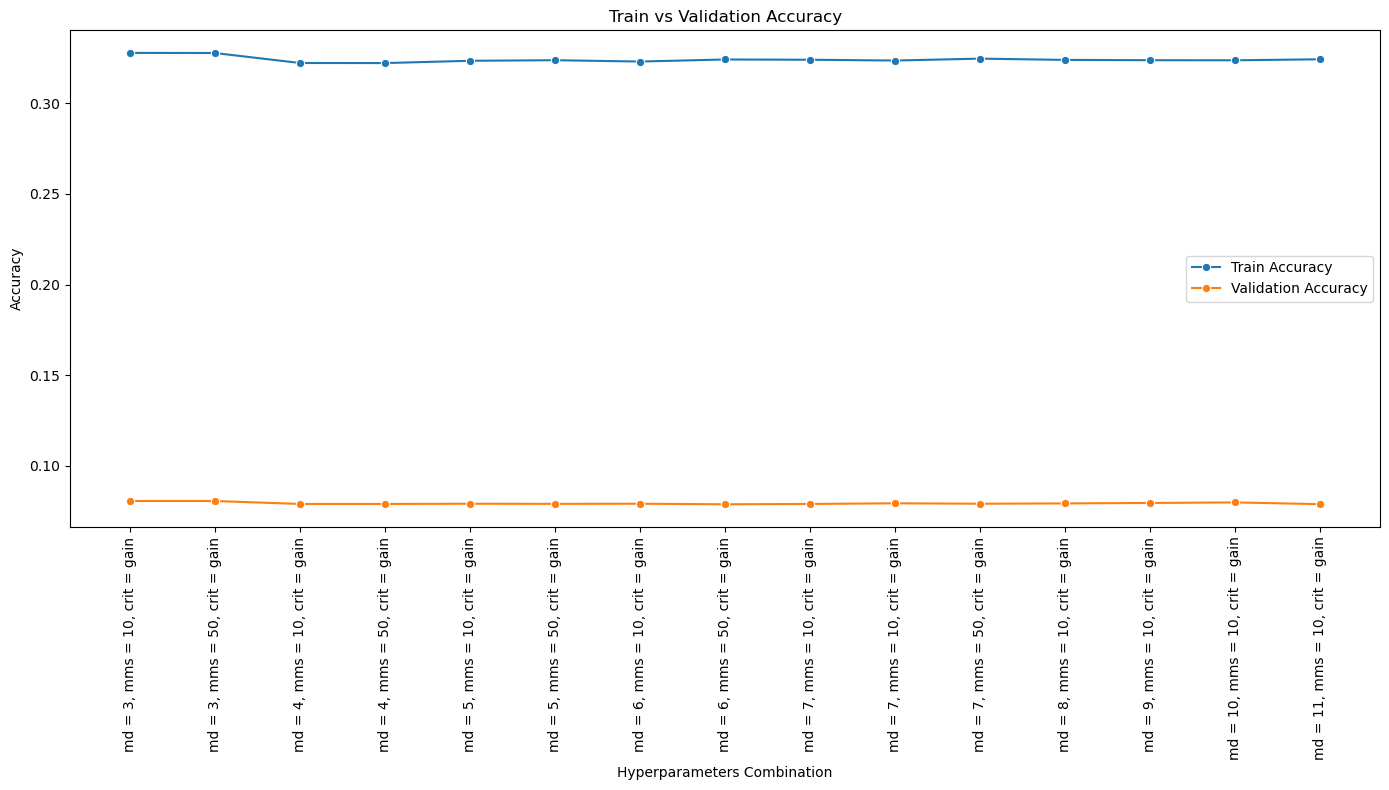

In [18]:
def train_vs_validation(df , metric) :
    
    if metric == 'Acc' :
        label = 'Accuracy'
        col = 'Acc'
    else :
        col = label = 'F1-Score'

    df['hyper_params'] = df.apply(lambda row : f'md = {row['max_depth']}, mms = {row['min_samples_split']}, crit = {row['criterion']}', axis = 1)
    df = df.sort_values(by = ['max_depth' , 'min_samples_split' , 'criterion']).reset_index(drop = True)
    df['comb_ind'] = df.index 

    plt.figure(figsize = (14,8))
    sns.lineplot(data = df , x = 'comb_ind' , y = f'train_{col}' , marker = 'o' , label = f'Train {label}') 
    sns.lineplot(data = df , x = 'comb_ind' , y = f'validation_{col}' , marker = 'o' , label = f'Validation {label}')
    plt.xlabel('Hyperparameters Combination')
    plt.ylabel(f'{label}')
    plt.title(f"Train vs Validation {label}")
    plt.xticks(df.index , labels = df['hyper_params'] , rotation = 90)
    plt.legend()
    plt.tight_layout()
    plt.show()

train_vs_validation(fine_df.copy() ,'Acc')

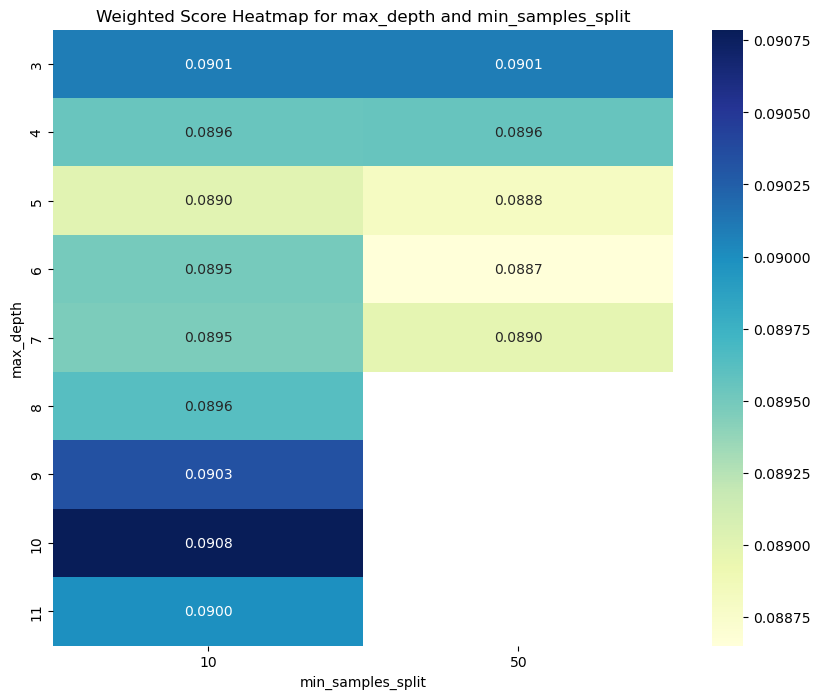

In [14]:
def hyper_pairs_heatmap(hyper_param_1 , hyper_param_2) :

    plt.figure(figsize = (10,8))
    sns.heatmap(fine_df.pivot_table(index = hyper_param_1 , columns = hyper_param_2 , values = 'weighted_score') , annot = True , cmap = 'YlGnBu' , fmt = '.4f')
    plt.title(f'Weighted Score Heatmap for {hyper_param_1} and {hyper_param_2}')
    plt.xlabel(hyper_param_2)
    plt.ylabel(hyper_param_1)
    plt.show()

hyper_pairs_heatmap('max_depth' , 'min_samples_split')

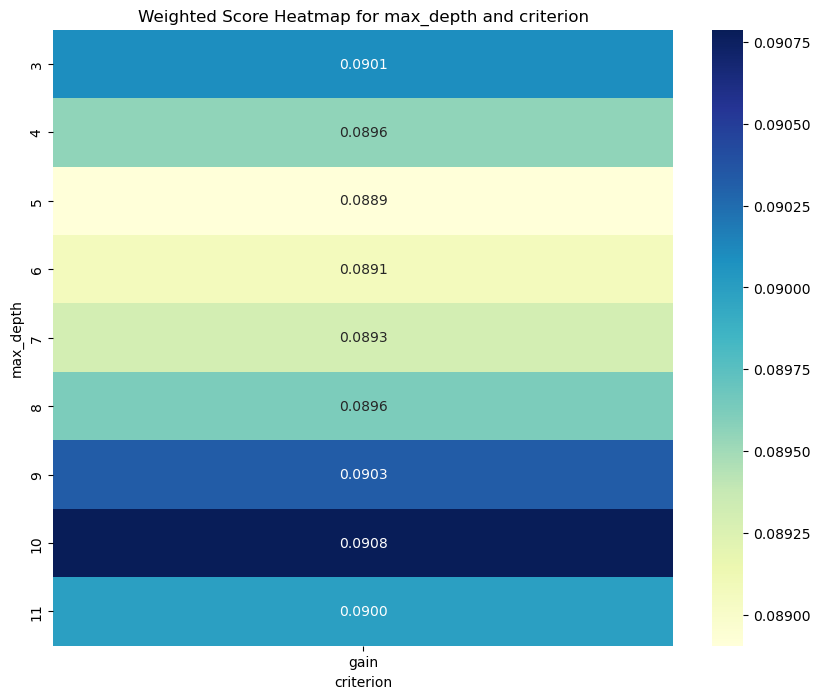

In [15]:
hyper_pairs_heatmap('max_depth' , 'criterion')

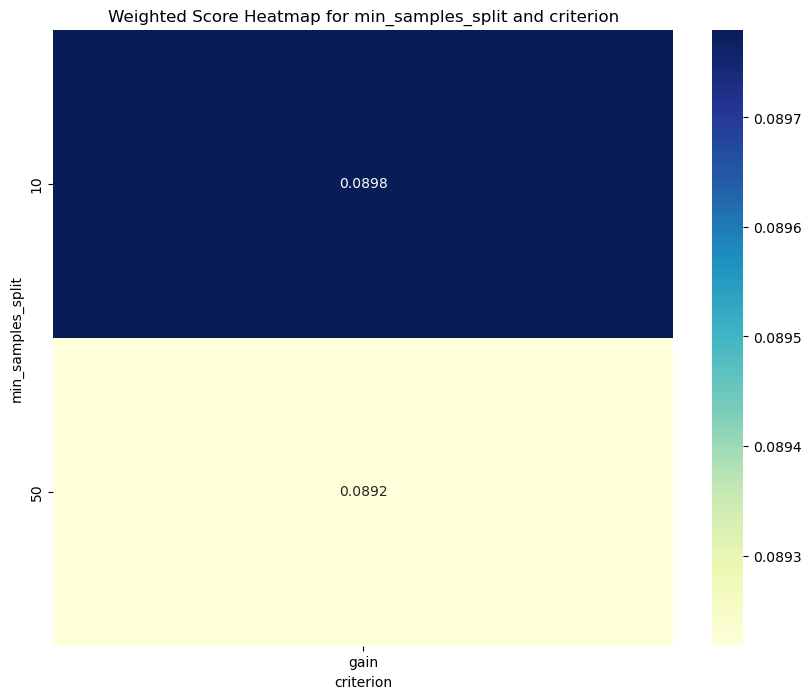

In [16]:
hyper_pairs_heatmap('min_samples_split' , 'criterion')

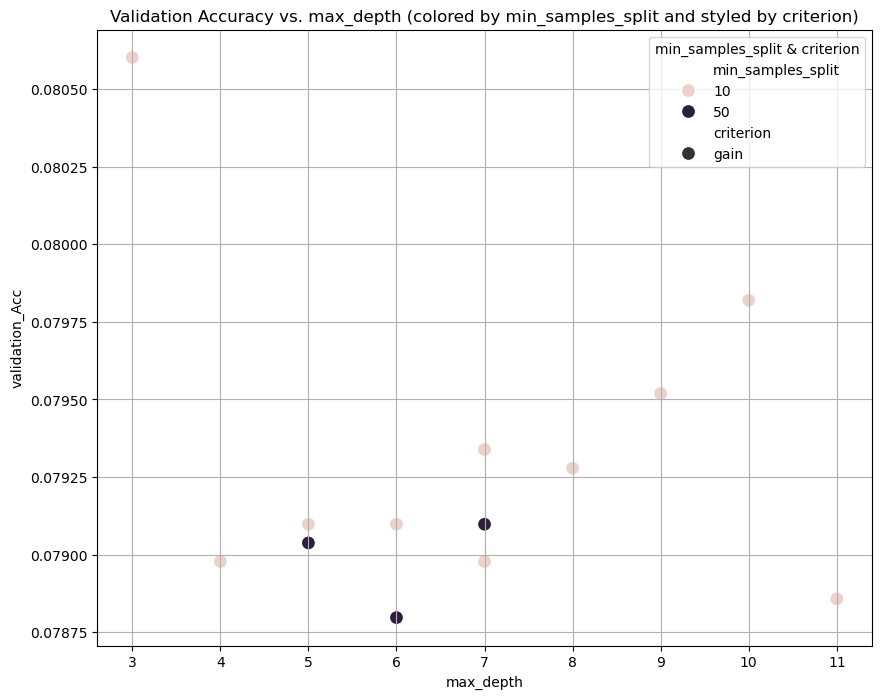

In [17]:
def scatter_plot(x_hyper_param , hue_hyper_param , style_hyper_param , metric) :
    
    if metric == 'Acc' :
        label = 'Accuracy'
    else :
        label = 'F1-Score' 
    plt.figure(figsize = (10,8))
    sns.scatterplot(data = fine_df , x = x_hyper_param , y = f'validation_{metric}' , hue = hue_hyper_param , style = style_hyper_param , s = 100 )
    plt.title(f'Validation {label} vs. {x_hyper_param} (colored by {hue_hyper_param} and styled by {style_hyper_param})')
    plt.xlabel(x_hyper_param)
    plt.ylabel(f'validation_{metric}')
    plt.grid(True)
    plt.legend(title = f'{hue_hyper_param} & {style_hyper_param}')
    plt.show()

scatter_plot('max_depth' , "min_samples_split" , "criterion" , 'Acc')